In [5]:
import json
import random

def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]


def save_jsonl(data, path):
    with open(path, "w", encoding="utf-8") as f:
        for row in data:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def split_all_datasets(
    stage1_file="xlsum_stage1_qa.jsonl",
    stage2_file="xlsum_stage2_compressed.jsonl",
    master_file="master_xlsum_processed.jsonl",
    train_ratio=0.8,
    seed=42
):

    # Load all datasets
    stage1 = load_jsonl(stage1_file)
    stage2 = load_jsonl(stage2_file)
    master = load_jsonl(master_file)

    # Safety check
    if not (len(stage1) == len(stage2) == len(master)):
        raise ValueError(
            f"Dataset sizes don't match!\n"
            f"Stage1: {len(stage1)}\n"
            f"Stage2: {len(stage2)}\n"
            f"Master: {len(master)}"
        )

    total = len(master)
    print(f"Loaded {total} aligned records.")

    # Generate one permutation for all datasets
    indices = list(range(total))
    random.seed(seed)
    random.shuffle(indices)

    split_idx = int(total * train_ratio)

    train_idx = indices[:split_idx]
    val_idx = indices[split_idx:]

    # Split using same indices
    stage1_train = [stage1[i] for i in train_idx]
    stage1_val = [stage1[i] for i in val_idx]

    stage2_train = [stage2[i] for i in train_idx]
    stage2_val = [stage2[i] for i in val_idx]

    master_train = [master[i] for i in train_idx]
    master_val = [master[i] for i in val_idx]

    # Save Stage 1
    save_jsonl(stage1_train, "train_stage1_qa.jsonl")
    save_jsonl(stage1_val, "val_stage1_qa.jsonl")

    # Save Stage 2
    save_jsonl(stage2_train, "train_stage2_compressed.jsonl")
    save_jsonl(stage2_val, "val_stage2_compressed.jsonl")

    # Save Master
    save_jsonl(master_train, "train_xlsum.jsonl")
    save_jsonl(master_val, "val_xlsum.jsonl")

    print("\n========== Split Summary ==========")
    print(f"Train: {len(train_idx)}")
    print(f"Validation: {len(val_idx)}")
    print("===================================")


# Run
split_all_datasets()

Loaded 281 aligned records.

========== Split Summary ==========
Train: 224
Validation: 57


In [4]:
master_file_path = "master_xlsum_processed.jsonl"
master_data = load_jsonl(master_file_path)

# Truncate the master data to 281 records
if len(master_data) > 281:
    truncated_master_data = master_data[:281]
    save_jsonl(truncated_master_data, master_file_path)
    print(f"Truncated '{master_file_path}' from {len(master_data)} to {len(truncated_master_data)} records.")
else:
    print(f"'{master_file_path}' already has {len(master_data)} records, no truncation needed.")


'master_xlsum_processed.jsonl' already has 281 records, no truncation needed.


In [8]:
import json

def clean_xlsum_file(input_file, output_file):
    """
    Removes unnecessary fields (e.g. article_id) from an XLSum JSONL file.

    Keeps only:
        - question
        - original_answer
        - tokens
        - labels
    """

    required_fields = [
        "question",
        "original_answer",
        "tokens",
        "labels"
    ]

    count = 0

    with open(input_file, "r", encoding="utf-8") as fin, \
         open(output_file, "w", encoding="utf-8") as fout:

        for line in fin:
            sample = json.loads(line)

            cleaned = {
                field: sample[field]
                for field in required_fields
                if field in sample
            }

            fout.write(
                json.dumps(cleaned, ensure_ascii=False) + "\n"
            )

            count += 1

    print(f"Saved {count} examples to {output_file}")

In [6]:
import zipfile
import json
import os

def merge_jsonl_from_zip(zip_path, output_file="merged_unclean.jsonl"):
    """
    Merge every .jsonl file inside a zip archive into a single JSONL file.

    Returns:
        output_file
    """

    total_examples = 0
    files_processed = 0

    with zipfile.ZipFile(zip_path, "r") as zf, \
         open(output_file, "w", encoding="utf-8") as fout:

        # Sort so merge order is deterministic
        jsonl_files = sorted(
            [f for f in zf.namelist()
             if f.endswith(".jsonl") and not f.startswith("__MACOSX")]
        )

        for filename in jsonl_files:
            files_processed += 1

            with zf.open(filename) as fin:
                for line in fin:
                    if not line.strip():
                        continue

                    sample = json.loads(line.decode("utf-8"))

                    fout.write(
                        json.dumps(sample, ensure_ascii=False) + "\n"
                    )

                    total_examples += 1

            print(f"✓ Merged {filename}")

    print("\n==========================")
    print(f"Files merged : {files_processed}")
    print(f"Examples     : {total_examples}")
    print(f"Saved to     : {output_file}")
    print("==========================")

    return output_file

In [9]:
merge_jsonl_from_zip(
    "unclean.zip",
    "merged_unclean.jsonl"
)

clean_xlsum_file(
    "merged_unclean.jsonl",
    "merged_clean.jsonl"
)

✓ Merged train_xlsum (1).jsonl
✓ Merged train_xlsum (2).jsonl
✓ Merged train_xlsum.jsonl
✓ Merged train_xlsum_1251_1500.jsonl
✓ Merged val_xlsum (1).jsonl
✓ Merged val_xlsum (2).jsonl
✓ Merged val_xlsum.jsonl
✓ Merged val_xlsum_1251_1500.jsonl

Files merged : 8
Examples     : 1042
Saved to     : merged_unclean.jsonl
Saved 1042 examples to merged_clean.jsonl


In [10]:
import zipfile
import json

def merge_clean_datasets(
    generated_file="merged_clean.jsonl",
    existing_zip="existing_data.zip",
    output_file="final_dataset.jsonl"
):
    """
    Merge:
        - merged_clean.jsonl
        - every JSONL inside existing_data.zip
    """

    total = 0

    with open(output_file, "w", encoding="utf-8") as fout:

        # First write generated data
        with open(generated_file, "r", encoding="utf-8") as fin:
            for line in fin:
                if line.strip():
                    fout.write(line)
                    total += 1

        # Then append existing train/val
        with zipfile.ZipFile(existing_zip, "r") as zf:

            jsonl_files = sorted(
                f for f in zf.namelist()
                if f.endswith(".jsonl")
            )

            for file in jsonl_files:
                print(f"Adding {file}")

                with zf.open(file) as fin:
                    for line in fin:
                        if line.strip():
                            fout.write(line.decode("utf-8"))
                            total += 1

    print(f"\nFinal dataset contains {total:,} samples")

In [11]:
import json
import matplotlib.pyplot as plt

def plot_context_compression(
    dataset_file="final_dataset.jsonl",
    bins=20
):
    """
    Compression % =
    retained_tokens / original_tokens * 100
    """

    compression = []

    with open(dataset_file, "r", encoding="utf-8") as f:
        for line in f:
            sample = json.loads(line)

            total_tokens = len(sample["tokens"])
            retained = sum(sample["labels"])

            if total_tokens == 0:
                continue

            compression.append(
                retained / total_tokens * 100
            )

    plt.figure(figsize=(10,6))

    plt.hist(
        compression,
        bins=bins,
        edgecolor="black"
    )

    plt.xlabel("Context Compression (%)")
    plt.ylabel("Number of Samples")
    plt.title("Distribution of Context Compression")

    plt.grid(alpha=0.3)

    plt.show()

    print(f"Samples : {len(compression):,}")
    print(f"Mean    : {sum(compression)/len(compression):.2f}%")
    print(f"Min     : {min(compression):.2f}%")
    print(f"Max     : {max(compression):.2f}%")

Adding train_indicqa.jsonl
Adding val_indicqa.jsonl

Final dataset contains 2,029 samples


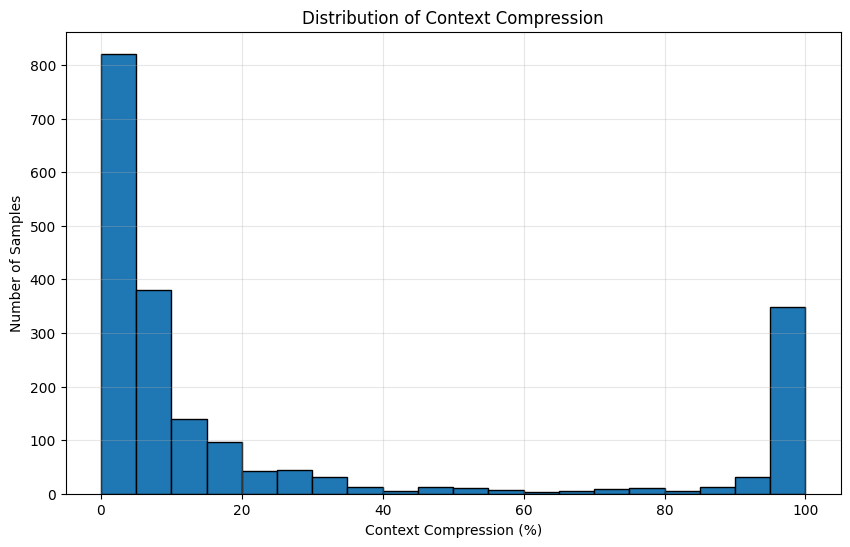

Samples : 2,029
Mean    : 27.05%
Min     : 0.00%
Max     : 100.00%


In [13]:
merge_clean_datasets(
    generated_file="merged_clean.jsonl",
    existing_zip="existing_data.zip",
    output_file="final_dataset.jsonl"
)

plot_context_compression("final_dataset.jsonl")

In [15]:
import numpy as np
import json

def get_compression_data(dataset_file="final_dataset.jsonl"):
    compression = []
    with open(dataset_file, "r", encoding="utf-8") as f:
        for line in f:
            sample = json.loads(line)
            total_tokens = len(sample["tokens"])
            retained = sum(sample["labels"])
            if total_tokens == 0:
                continue
            compression.append(retained / total_tokens * 100)
    return compression

compression = get_compression_data()
arr = np.array(compression)

print("\nCompression Statistics")
print(f"Mean   : {arr.mean():.2f}%")
print(f"Median : {np.median(arr):.2f}%")
print(f"5th    : {np.percentile(arr, 5):.2f}%")
print(f"25th   : {np.percentile(arr,25):.2f}%")
print(f"75th   : {np.percentile(arr,75):.2f}%")
print(f"95th   : {np.percentile(arr,95):.2f}%")


Compression Statistics
Mean   : 27.05%
Median : 6.73%
5th    : 1.08%
25th   : 3.21%
75th   : 29.54%
95th   : 100.00%


In [16]:
ranges = [
    (0, 1),
    (1, 2),
    (2, 5),
    (5, 10),
    (10, 25),
    (25, 50),
    (50, 75),
    (75, 99),
    (99, 100),
]

for low, high in ranges:
    count = sum(low <= c < high for c in compression)
    print(f"{low:>2}-{high:<3}% : {count}")

 0-1  % : 90
 1-2  % : 172
 2-5  % : 559
 5-10 % : 381
10-25 % : 277
25-50 % : 106
50-75 % : 37
75-99 % : 75
99-100% : 5


In [17]:
import json
import matplotlib.pyplot as plt
import numpy as np

def analyse_positive_tokens(jsonl_file):
    positive_counts = []

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            sample = json.loads(line)

            positives = sum(sample["labels"])
            positive_counts.append(positives)

    positive_counts = np.array(positive_counts)

    print("Statistics")
    print("----------------------")
    print(f"Samples : {len(positive_counts)}")
    print(f"Mean    : {positive_counts.mean():.2f}")
    print(f"Median  : {np.median(positive_counts):.2f}")
    print(f"Min     : {positive_counts.min()}")
    print(f"Max     : {positive_counts.max()}")

    print("\nPercentiles")
    print("----------------------")
    print(f"5%   : {np.percentile(positive_counts,5):.0f}")
    print(f"25%  : {np.percentile(positive_counts,25):.0f}")
    print(f"50%  : {np.percentile(positive_counts,50):.0f}")
    print(f"75%  : {np.percentile(positive_counts,75):.0f}")
    print(f"95%  : {np.percentile(positive_counts,95):.0f}")

    plt.figure(figsize=(10,5))
    plt.hist(
        positive_counts,
        bins=40,
        edgecolor="black"
    )

    plt.xlabel("Number of Positive Tokens")
    plt.ylabel("Samples")
    plt.title("Distribution of Positive Labels")

    plt.grid(alpha=0.3)

    plt.show()

    return positive_counts

Statistics
----------------------
Samples : 2029
Mean    : 88.33
Median  : 25.00
Min     : 0
Max     : 841

Percentiles
----------------------
5%   : 5
25%  : 14
50%  : 25
75%  : 90
95%  : 371


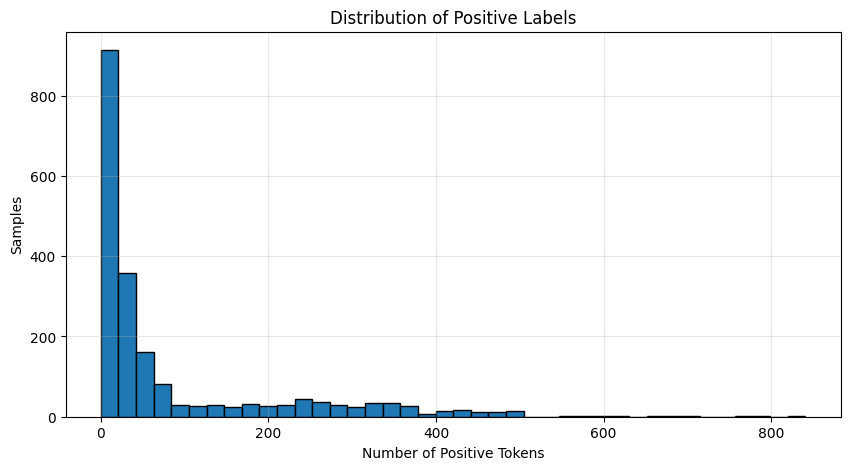

In [18]:
positive_counts = analyse_positive_tokens("final_dataset.jsonl")

In [19]:
import json

def show_smallest_positive_examples(
    jsonl_file,
    max_positive=5,
    n=10
):
    shown = 0

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            sample = json.loads(line)

            positives = sum(sample["labels"])

            if positives <= max_positive:
                print("="*80)
                print(f"Positive tokens : {positives}")
                print(f"Question : {sample['question']}")
                print(f"Answer   : {sample['original_answer']}")
                print(f"Context length : {len(sample['tokens'])}")
                print()

                shown += 1

                if shown == n:
                    break

In [21]:
import json
from collections import Counter

def positive_token_counts(jsonl_file):
    counter = Counter()

    with open(jsonl_file, "r", encoding="utf-8") as f:
        for line in f:
            sample = json.loads(line)
            counter[sum(sample["labels"])] += 1

    print("Positive Tokens -> Samples")
    print("-" * 30)

    for i in range(21):
        print(f"{i:2d} -> {counter[i]}")

    return counter

In [22]:
counter = positive_token_counts("final_dataset.jsonl")

Positive Tokens -> Samples
------------------------------
 0 -> 17
 1 -> 9
 2 -> 17
 3 -> 21
 4 -> 19
 5 -> 21
 6 -> 28
 7 -> 34
 8 -> 39
 9 -> 49
10 -> 62
11 -> 65
12 -> 61
13 -> 58
14 -> 55
15 -> 65
16 -> 58
17 -> 47
18 -> 51
19 -> 38
20 -> 45


In [24]:
import json

def filter_dataset(
    input_file="final_dataset.jsonl",
    output_file="final_dataset_filtered.jsonl"
):
    """
    Removes invalid samples:
      - sum(labels) == 0
      - len(tokens) != len(labels)
      - empty question
      - empty answer
      - empty tokens
    """

    kept = 0
    removed_zero_labels = 0
    removed_length_mismatch = 0
    removed_empty = 0

    with open(input_file, "r", encoding="utf-8") as fin, \
         open(output_file, "w", encoding="utf-8") as fout:

        for line in fin:
            sample = json.loads(line)

            tokens = sample["tokens"]
            labels = sample["labels"]

            # Length mismatch
            if len(tokens) != len(labels):
                removed_length_mismatch += 1
                continue

            # No positive labels
            if sum(labels) == 0:
                removed_zero_labels += 1
                continue

            # Empty fields
            if (
                len(tokens) == 0
                or sample["question"].strip() == ""
                or sample["original_answer"].strip() == ""
            ):
                removed_empty += 1
                continue

            fout.write(json.dumps(sample, ensure_ascii=False) + "\n")
            kept += 1

    print("=" * 50)
    print("Filtering Summary")
    print("=" * 50)
    print(f"Kept                     : {kept}")
    print(f"Removed (0 positives)    : {removed_zero_labels}")
    print(f"Removed (length mismatch): {removed_length_mismatch}")
    print(f"Removed (empty fields)   : {removed_empty}")
    print(f"Final dataset size       : {kept}")

In [25]:
filter_dataset(
    input_file="final_dataset.jsonl",
    output_file="final_dataset_filtered.jsonl"
)

Filtering Summary
Kept                     : 2012
Removed (0 positives)    : 17
Removed (length mismatch): 0
Removed (empty fields)   : 0
Final dataset size       : 2012
